In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", None)

PROCESSED_DATA_DIR = Path("C:\\Users\\aabre\\Documents\\data-science-projects\\nba-player-archetype-clustering\\data\\processed\\2025_26")
FIGURES_DIR = Path("C:\\Users\\aabre\\Documents\\data-science-projects\\nba-player-archetype-clustering\\figures")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

players = pd.read_csv(PROCESSED_DATA_DIR / "STYLE_FEATURES_V1.csv")
players.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PLAYER_ID                450 non-null    int64  
 1   PLAYER_NAME              450 non-null    str    
 2   USG_RATE                 450 non-null    float64
 3   TOUCHES_PER_100          450 non-null    float64
 4   POT_AST_PER_100          450 non-null    float64
 5   DRIVES_PER_100           450 non-null    float64
 6   CATCH_SHOOT_FGA_PER_100  450 non-null    float64
 7   PULL_UP_FGA_PER_100      450 non-null    float64
 8   PAINT_TOUCHES_PER_100    450 non-null    float64
 9   SCREEN_AST_PER_100       450 non-null    float64
 10  DEFLECTIONS_PER_100      450 non-null    float64
 11  STL_PCT                  450 non-null    float64
 12  BLK_PCT                  450 non-null    float64
 13  BOXOUTS_PER_100          450 non-null    float64
 14  PAINT_FGA_RATE           450 non-null

In [19]:
features = players.drop(["PLAYER_ID", "PLAYER_NAME"], axis=1).columns.to_list()

print(players[features].isna().sum())
print(np.isinf(players[features]).sum())
print(players[features].std())

USG_RATE                   0
TOUCHES_PER_100            0
POT_AST_PER_100            0
DRIVES_PER_100             0
CATCH_SHOOT_FGA_PER_100    0
PULL_UP_FGA_PER_100        0
PAINT_TOUCHES_PER_100      0
SCREEN_AST_PER_100         0
DEFLECTIONS_PER_100        0
STL_PCT                    0
BLK_PCT                    0
BOXOUTS_PER_100            0
PAINT_FGA_RATE             0
MIDRANGE_FGA_RATE          0
dtype: int64
USG_RATE                   0
TOUCHES_PER_100            0
POT_AST_PER_100            0
DRIVES_PER_100             0
CATCH_SHOOT_FGA_PER_100    0
PULL_UP_FGA_PER_100        0
PAINT_TOUCHES_PER_100      0
SCREEN_AST_PER_100         0
DEFLECTIONS_PER_100        0
STL_PCT                    0
BLK_PCT                    0
BOXOUTS_PER_100            0
PAINT_FGA_RATE             0
MIDRANGE_FGA_RATE          0
dtype: int64
USG_RATE                    0.053039
TOUCHES_PER_100            18.576337
POT_AST_PER_100             4.811384
DRIVES_PER_100              8.052690
CATCH_SHOOT_FG

In [20]:
X = players[features].copy()
X.shape

(450, 14)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns = features, index = players.index)

print(X_scaled_df.mean().round(2))
print(X_scaled_df.std().round(2))
X_scaled_df.head()

USG_RATE                   0.0
TOUCHES_PER_100           -0.0
POT_AST_PER_100           -0.0
DRIVES_PER_100            -0.0
CATCH_SHOOT_FGA_PER_100    0.0
PULL_UP_FGA_PER_100       -0.0
PAINT_TOUCHES_PER_100      0.0
SCREEN_AST_PER_100         0.0
DEFLECTIONS_PER_100       -0.0
STL_PCT                   -0.0
BLK_PCT                    0.0
BOXOUTS_PER_100            0.0
PAINT_FGA_RATE             0.0
MIDRANGE_FGA_RATE         -0.0
dtype: float64
USG_RATE                   1.0
TOUCHES_PER_100            1.0
POT_AST_PER_100            1.0
DRIVES_PER_100             1.0
CATCH_SHOOT_FGA_PER_100    1.0
PULL_UP_FGA_PER_100        1.0
PAINT_TOUCHES_PER_100      1.0
SCREEN_AST_PER_100         1.0
DEFLECTIONS_PER_100        1.0
STL_PCT                    1.0
BLK_PCT                    1.0
BOXOUTS_PER_100            1.0
PAINT_FGA_RATE             1.0
MIDRANGE_FGA_RATE          1.0
dtype: float64


,USG_RATE,TOUCHES_PER_100,POT_AST_PER_100,DRIVES_PER_100,CATCH_SHOOT_FGA_PER_100,PULL_UP_FGA_PER_100,PAINT_TOUCHES_PER_100,SCREEN_AST_PER_100,DEFLECTIONS_PER_100,STL_PCT,BLK_PCT,BOXOUTS_PER_100,PAINT_FGA_RATE,MIDRANGE_FGA_RATE
0,-0.942783,-0.505670,-0.645524,-0.910562,1.267531,-0.047780,-0.939171,-0.539604,-0.775523,-1.405032,-1.071490,-0.387096,-2.060258,-0.577309
1,0.189714,-0.098932,0.227509,0.894536,-0.678260,-0.313349,-0.502151,-0.699726,-0.839722,-0.629881,-0.898473,-0.946035,0.755379,-0.862930
2,0.529463,0.205146,-0.159975,-0.621380,-0.136145,0.246436,0.877706,0.090241,-1.566525,-0.839818,-0.462470,-0.469305,-0.069969,0.656446
3,-0.489784,-0.395123,-0.301470,-0.113743,1.304167,-0.149876,-1.029892,-0.665542,-0.738104,0.080673,-0.946918,-0.667978,-1.106922,-0.261020
4,0.095339,0.073847,-0.734166,0.302626,0.892055,0.165172,-0.723176,-0.345877,-1.231835,-0.969010,0.056580,-0.709764,-0.699021,0.445300


In [5]:
test_kmeans = KMeans(n_clusters=5, random_state=28, n_init=20)
test_labels = test_kmeans.fit_predict(X_scaled)
pd.Series(test_labels).value_counts().sort_index()

0    159
1    120
2     41
3     73
4     57
Name: count, dtype: int64

In [22]:
k_values = range(2, 13)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=28, n_init=20)
    labels = model.fit_predict(X_scaled)
    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, labels),
        "smallest_cluster": pd.Series(labels).value_counts().min(),
        "largest_cluster": pd.Series(labels).value_counts().max()
    })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster,largest_cluster
0,2,4525.546387,0.329562,175.659501,1.164915,86,364
1,3,3395.213753,0.273125,191.216157,1.308508,77,240
2,4,3011.783635,0.224017,162.311848,1.418647,71,177
3,5,2785.833088,0.219348,140.335425,1.458756,41,159
4,6,2603.666369,0.192002,126.066239,1.636050,46,140
5,7,2446.801822,0.170076,116.271969,1.653733,43,92
6,8,2340.747802,0.167727,106.802833,1.629361,32,78
7,9,2239.782644,0.165657,99.929108,1.589757,25,76
8,10,2153.634834,0.165386,94.125143,1.579429,16,62
9,11,2066.158676,0.169200,89.957096,1.550611,17,67


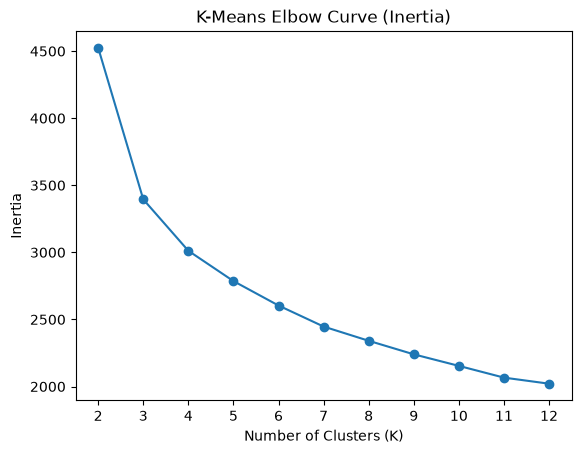

In [23]:
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve (Inertia)")
plt.xticks(kmeans_results["k"])
plt.show()

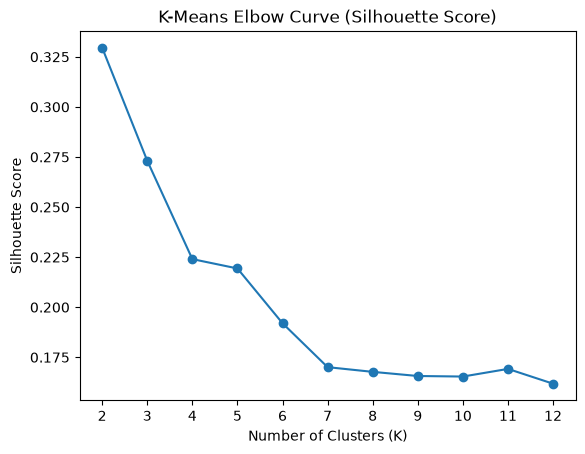

In [24]:
plt.plot(kmeans_results["k"], kmeans_results["silhouette_score"], marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Elbow Curve (Silhouette Score)")
plt.xticks(kmeans_results["k"])
plt.show()

In [31]:
player_names = players[["PLAYER_ID", "PLAYER_NAME"]]

def player_lists(k, players = player_names, X_scaled = X_scaled):
    model = KMeans(n_clusters=k, random_state=28, n_init=20)
    labels = model.fit_predict(X_scaled)
    result = players.copy()
    result["CLUSTER"] = labels
    return model, result

def print_player_lists(player_list):
    for cluster in sorted(np.unique(player_list["CLUSTER"])):
        print("=" * 50)
        print(f"Cluster {cluster}")
        display(player_list[player_list["CLUSTER"] == cluster].head(25))

In [32]:
model_k4, players_k4 = player_lists(4)

print_player_lists(players_k4)

Cluster 0


,PLAYER_ID,PLAYER_NAME,CLUSTER
10,1627936,Alex Caruso,0
16,1641748,Andre Jackson Jr.,0
26,1641709,Ausar Thompson,0
34,1643016,Bez Mbeng,0
35,1641731,Bilal Coulibaly,0
49,1642964,Brooks Barnhizer,0
50,1628971,Bruce Brown,0
57,1628997,Caleb Martin,0
61,1641715,Cam Whitmore,0
63,1626166,Cameron Payne,0


Cluster 1


,PLAYER_ID,PLAYER_NAME,CLUSTER
0,1631260,AJ Green,1
1,1642358,AJ Johnson,1
2,203932,Aaron Gordon,1
3,1628988,Aaron Holiday,1
4,1630174,Aaron Nesmith,1
5,1630598,Aaron Wiggins,1
6,1642846,Ace Bailey,1
9,201143,Al Horford,1
14,1629599,Amir Coffey,1
18,203952,Andrew Wiggins,1


Cluster 2


,PLAYER_ID,PLAYER_NAME,CLUSTER
8,1642349,Ajay Mitchell,2
12,1630578,Alperen Sengun,2
13,1641708,Amen Thompson,2
17,1629614,Andrew Nembhard,2
19,1629014,Anfernee Simons,2
20,1641710,Anthony Black,2
22,1630162,Anthony Edwards,2
27,1630559,Austin Reaves,2
31,1642879,Ben Saraf,2
33,1631097,Bennedict Mathurin,2


Cluster 3


,PLAYER_ID,PLAYER_NAME,CLUSTER
7,1641737,Adem Bona,3
11,1642259,Alex Sarr,3
15,203083,Andre Drummond,3
21,203076,Anthony Davis,3
23,1630264,Anthony Gill,3
24,1630574,Ariel Hukporti,3
41,1642382,Branden Carlson,3
68,1643052,Chaney Johnson,3
70,1631096,Chet Holmgren,3
72,1631132,Christian Koloko,3


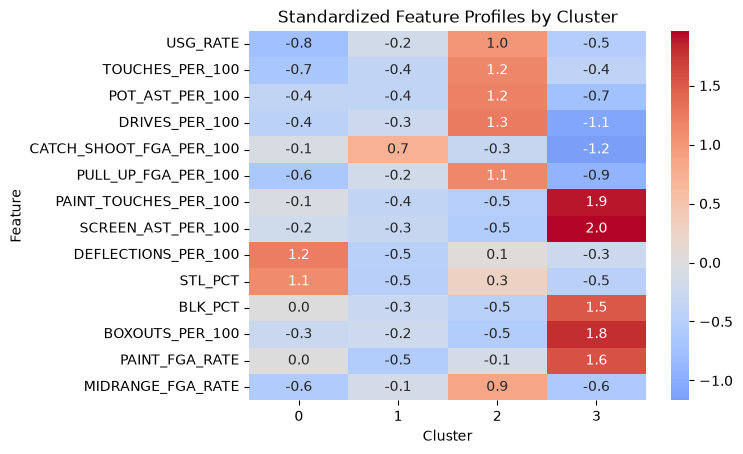

In [34]:
def centroid_feature_profile(model, features = features):
    centroids = pd.DataFrame(model.cluster_centers_, columns = features).T
    sns.heatmap(centroids, annot=True, fmt=".1f", center = 0, cmap="coolwarm")
    plt.title("Standardized Feature Profiles by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Feature")
    return centroids, plt.show()

centroids_k4 = centroid_feature_profile(model_k4)

Cluster 0


,PLAYER_ID,PLAYER_NAME,CLUSTER
0,1631260,AJ Green,0
1,1642358,AJ Johnson,0
2,203932,Aaron Gordon,0
3,1628988,Aaron Holiday,0
4,1630174,Aaron Nesmith,0
5,1630598,Aaron Wiggins,0
6,1642846,Ace Bailey,0
14,1629599,Amir Coffey,0
18,203952,Andrew Wiggins,0
28,1630245,Ayo Dosunmu,0


Cluster 1


,PLAYER_ID,PLAYER_NAME,CLUSTER
8,1642349,Ajay Mitchell,1
13,1641708,Amen Thompson,1
17,1629614,Andrew Nembhard,1
19,1629014,Anfernee Simons,1
20,1641710,Anthony Black,1
22,1630162,Anthony Edwards,1
27,1630559,Austin Reaves,1
31,1642879,Ben Saraf,1
33,1631097,Bennedict Mathurin,1
37,1631104,Blake Wesley,1


Cluster 2


,PLAYER_ID,PLAYER_NAME,CLUSTER
9,201143,Al Horford,2
11,1642259,Alex Sarr,2
12,1630578,Alperen Sengun,2
21,203076,Anthony Davis,2
25,1642854,Asa Newell,2
29,1628389,Bam Adebayo,2
41,1642382,Branden Carlson,2
48,201572,Brook Lopez,2
68,1643052,Chaney Johnson,2
70,1631096,Chet Holmgren,2


Cluster 3


,PLAYER_ID,PLAYER_NAME,CLUSTER
10,1627936,Alex Caruso,3
16,1641748,Andre Jackson Jr.,3
26,1641709,Ausar Thompson,3
34,1643016,Bez Mbeng,3
35,1641731,Bilal Coulibaly,3
49,1642964,Brooks Barnhizer,3
50,1628971,Bruce Brown,3
57,1628997,Caleb Martin,3
61,1641715,Cam Whitmore,3
63,1626166,Cameron Payne,3


Cluster 4


,PLAYER_ID,PLAYER_NAME,CLUSTER
7,1641737,Adem Bona,4
15,203083,Andre Drummond,4
23,1630264,Anthony Gill,4
24,1630574,Ariel Hukporti,4
72,1631132,Christian Koloko,4
73,203991,Clint Capela,4
78,1642867,Collin Murray-Boyles,4
88,1629655,Daniel Gafford,4
93,1630549,Day'Ron Sharpe,4
99,1629028,Deandre Ayton,4


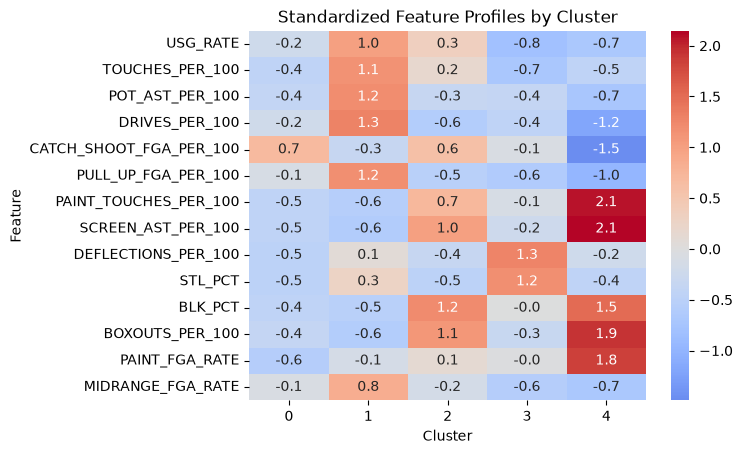

In [35]:
model_k5, players_k5 = player_lists(5)

print_player_lists(players_k5)

centroids_k5 = centroid_feature_profile(model_k5)

Cluster 0


,PLAYER_ID,PLAYER_NAME,CLUSTER
10,1627936,Alex Caruso,0
16,1641748,Andre Jackson Jr.,0
26,1641709,Ausar Thompson,0
34,1643016,Bez Mbeng,0
35,1641731,Bilal Coulibaly,0
49,1642964,Brooks Barnhizer,0
50,1628971,Bruce Brown,0
57,1628997,Caleb Martin,0
61,1641715,Cam Whitmore,0
66,1641717,Cason Wallace,0


Cluster 1


,PLAYER_ID,PLAYER_NAME,CLUSTER
9,201143,Al Horford,1
11,1642259,Alex Sarr,1
21,203076,Anthony Davis,1
25,1642854,Asa Newell,1
29,1628389,Bam Adebayo,1
41,1642382,Branden Carlson,1
48,201572,Brook Lopez,1
68,1643052,Chaney Johnson,1
70,1631096,Chet Holmgren,1
103,1642852,Derik Queen,1


Cluster 2


...

,PLAYER_ID,PLAYER_NAME,CLUSTER
17,1629614,Andrew Nembhard,3
19,1629014,Anfernee Simons,3
22,1630162,Anthony Edwards,3
33,1631097,Bennedict Mathurin,3
43,1627742,Brandon Ingram,3
52,1642267,Bub Carrington,3
54,203468,CJ McCollum,3
55,1630595,Cade Cunningham,3
60,1630560,Cam Thomas,3
74,1629632,Coby White,3


Cluster 4


,PLAYER_ID,PLAYER_NAME,CLUSTER
8,1642349,Ajay Mitchell,4
12,1630578,Alperen Sengun,4
13,1641708,Amen Thompson,4
20,1641710,Anthony Black,4
27,1630559,Austin Reaves,4
28,1630245,Ayo Dosunmu,4
31,1642879,Ben Saraf,4
37,1631104,Blake Wesley,4
40,1630538,Bones Hyland,4
42,1641764,Brandin Podziemski,4


Cluster 5


,PLAYER_ID,PLAYER_NAME,CLUSTER
0,1631260,AJ Green,5
1,1642358,AJ Johnson,5
2,203932,Aaron Gordon,5
3,1628988,Aaron Holiday,5
4,1630174,Aaron Nesmith,5
5,1630598,Aaron Wiggins,5
6,1642846,Ace Bailey,5
14,1629599,Amir Coffey,5
18,203952,Andrew Wiggins,5
30,1631248,Baylor Scheierman,5


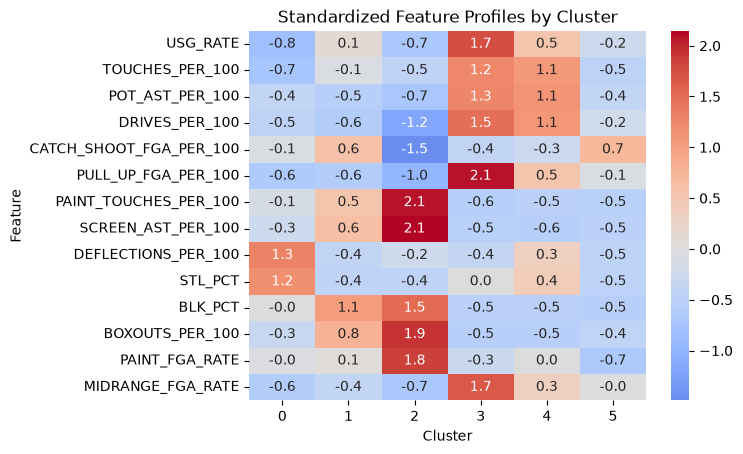

In [36]:
model_k6, players_k6 = player_lists(6)

print_player_lists(players_k6)

centroids_k6 = centroid_feature_profile(model_k6)

Cluster 0


,PLAYER_ID,PLAYER_NAME,CLUSTER
0,1631260,AJ Green,0
3,1628988,Aaron Holiday,0
14,1629599,Amir Coffey,0
30,1631248,Baylor Scheierman,0
32,1641767,Ben Sheppard,0
36,1642396,Blake Hinson,0
51,1631121,Bryce McGowens,0
62,1629661,Cameron Johnson,0
65,1642868,Carter Bryant,0
69,1642404,Chaz Lanier,0


Cluster 1


,PLAYER_ID,PLAYER_NAME,CLUSTER
10,1627936,Alex Caruso,1
16,1641748,Andre Jackson Jr.,1
26,1641709,Ausar Thompson,1
34,1643016,Bez Mbeng,1
35,1641731,Bilal Coulibaly,1
49,1642964,Brooks Barnhizer,1
50,1628971,Bruce Brown,1
57,1628997,Caleb Martin,1
63,1626166,Cameron Payne,1
66,1641717,Cason Wallace,1


Cluster 2


...

,PLAYER_ID,PLAYER_NAME,CLUSTER
17,1629614,Andrew Nembhard,4
22,1630162,Anthony Edwards,4
43,1627742,Brandon Ingram,4
52,1642267,Bub Carrington,4
54,203468,CJ McCollum,4
55,1630595,Cade Cunningham,4
60,1630560,Cam Thomas,4
74,1629632,Coby White,4
80,1642843,Cooper Flagg,4
84,1626156,D'Angelo Russell,4


Cluster 5


,PLAYER_ID,PLAYER_NAME,CLUSTER
7,1641737,Adem Bona,5
15,203083,Andre Drummond,5
23,1630264,Anthony Gill,5
24,1630574,Ariel Hukporti,5
72,1631132,Christian Koloko,5
73,203991,Clint Capela,5
78,1642867,Collin Murray-Boyles,5
88,1629655,Daniel Gafford,5
93,1630549,Day'Ron Sharpe,5
99,1629028,Deandre Ayton,5


Cluster 6


,PLAYER_ID,PLAYER_NAME,CLUSTER
9,201143,Al Horford,6
11,1642259,Alex Sarr,6
21,203076,Anthony Davis,6
25,1642854,Asa Newell,6
29,1628389,Bam Adebayo,6
41,1642382,Branden Carlson,6
48,201572,Brook Lopez,6
68,1643052,Chaney Johnson,6
70,1631096,Chet Holmgren,6
103,1642852,Derik Queen,6


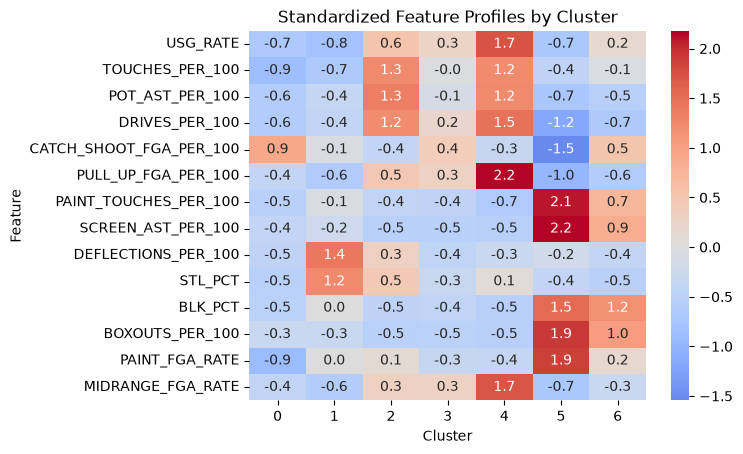

In [37]:
model_k7, players_k7 = player_lists(7)

print_player_lists(players_k7)

centroids_k7 = centroid_feature_profile(model_k7)

In [40]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({"PC": range(1, len(pca.explained_variance_ratio_) + 1), 
                                   "variance_ratio": pca.explained_variance_ratio_})
explained_variance["cumulative_variance"] = explained_variance["variance_ratio"].cumsum()
explained_variance

,PC,variance_ratio,cumulative_variance
0,1,0.418699,0.418699
1,2,0.206015,0.624715
2,3,0.140042,0.764757
3,4,0.062393,0.827150
4,5,0.053248,0.880398
5,6,0.035397,0.915794
6,7,0.025585,0.941379
7,8,0.015230,0.956609
8,9,0.013263,0.969872
9,10,0.011180,0.981052


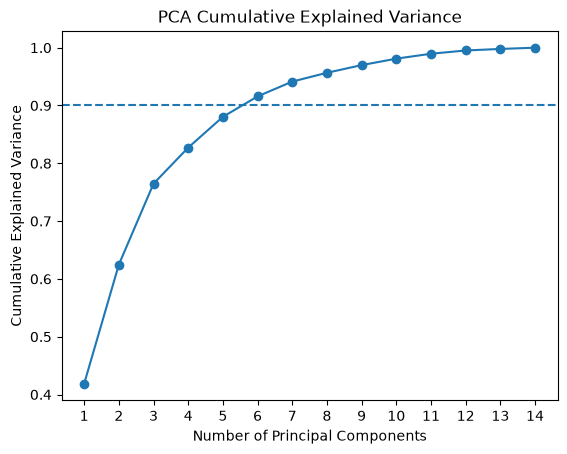

In [41]:
plt.plot(explained_variance["PC"], explained_variance["cumulative_variance"], marker = "o")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(0.9, linestyle = "--")
plt.xticks(explained_variance["PC"])
plt.show()

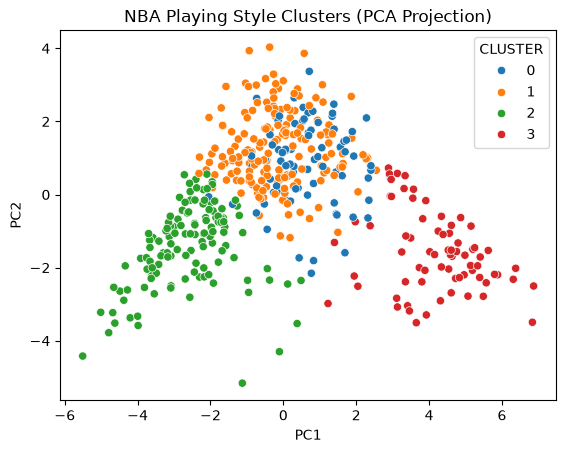

In [48]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df_2 = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df_2["PLAYER_NAME"] = players["PLAYER_NAME"].values
pca_df_2["CLUSTER"] = model_k4.labels_

sns.scatterplot(pca_df_2, x="PC1", y="PC2", hue="CLUSTER", palette="tab10")
plt.title("NBA Playing Style Clusters (PCA Projection)")
plt.show()

In [54]:
pca_2_loadings = pd.DataFrame(pca_2.components_.T, index=features, columns=["PC1", "PC2"])

print(pca_2_loadings["PC1"].sort_values(ascending=False))
print(pca_2_loadings["PC2"].sort_values(ascending=False))

PAINT_TOUCHES_PER_100      0.339174
SCREEN_AST_PER_100         0.337227
BOXOUTS_PER_100            0.328172
BLK_PCT                    0.294894
PAINT_FGA_RATE             0.253757
DEFLECTIONS_PER_100       -0.022106
STL_PCT                   -0.085352
CATCH_SHOOT_FGA_PER_100   -0.129152
TOUCHES_PER_100           -0.241332
MIDRANGE_FGA_RATE         -0.247241
USG_RATE                  -0.247920
POT_AST_PER_100           -0.281956
PULL_UP_FGA_PER_100       -0.336015
DRIVES_PER_100            -0.338372
Name: PC1, dtype: float64
CATCH_SHOOT_FGA_PER_100    0.422243
DEFLECTIONS_PER_100       -0.031776
STL_PCT                   -0.087217
MIDRANGE_FGA_RATE         -0.168604
PULL_UP_FGA_PER_100       -0.169732
BLK_PCT                   -0.192517
BOXOUTS_PER_100           -0.199327
SCREEN_AST_PER_100        -0.229167
DRIVES_PER_100            -0.254520
PAINT_TOUCHES_PER_100     -0.275027
USG_RATE                  -0.301189
POT_AST_PER_100           -0.311317
TOUCHES_PER_100           -0.379490
PA